In [127]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [128]:
df = pd.read_csv("netflix_titles.csv")

In [129]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [130]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [131]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [132]:
df.shape

(8807, 12)

In [133]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [134]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [136]:
df.duplicated().sum()

0

In [137]:
missing_value = df.isnull().sum()
missing_value

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

* Missing Value Percentage

In [138]:
missing_value*100/len(df)

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64

* Handling Director Missing value

In [139]:
df['director'].isnull().sum()

2634

In [140]:
df['director'] = df['director'].fillna('Unknown')

* Handling Country Missing Value

In [141]:
df['country'] = df['country'].fillna("Unknown")

* Handling Cast Missing Value

In [142]:
df['cast'] = df['cast'].fillna('Unknown')

* Handling Rating Missing value

In [143]:
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

* Converting date_added to datetime

In [144]:
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed', errors='coerce')


In [145]:
df['add_month_name'] = df['date_added'].dt.month_name()

* Movies vs TV Shows

In [146]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [147]:
df['rating'].mode()[0]

'TV-MA'

In [148]:
df['rating'].value_counts()

rating
TV-MA       3211
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [149]:
df['release_year'].value_counts().sort_index()

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

* Which countries produce the most Netflix content?

In [150]:
df['country'].value_counts()

country
United States                             2818
India                                      972
Unknown                                    831
United Kingdom                             419
Japan                                      245
                                          ... 
Romania, Bulgaria, Hungary                   1
Uruguay, Guatemala                           1
France, Senegal, Belgium                     1
Mexico, United States, Spain, Colombia       1
United Arab Emirates, Jordan                 1
Name: count, Length: 749, dtype: int64

In [151]:
countries= df['country'].str.strip(', ').str.title()
country_list = countries.explode()
country_count = country_list.value_counts()
country_count.head(10)

country
United States     2819
India              972
Unknown            831
United Kingdom     421
Japan              245
South Korea        200
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

* Which directors have the most titles on Netflix?

In [152]:
list_director = df['director'].str.strip().str.split(', ').explode()
list_director

0       Kirsten Johnson
1               Unknown
2       Julien Leclercq
3               Unknown
4               Unknown
             ...       
8802      David Fincher
8803            Unknown
8804    Ruben Fleischer
8805       Peter Hewitt
8806        Mozez Singh
Name: director, Length: 9612, dtype: object

# Visualization

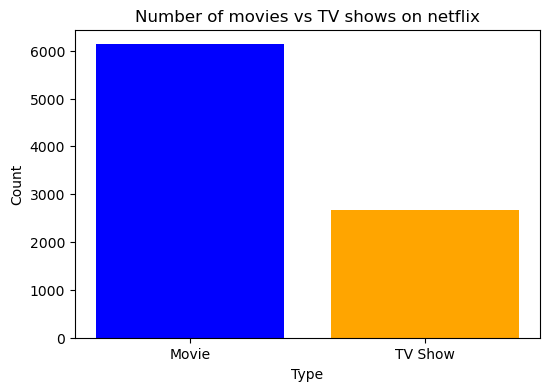

In [153]:
type_count = df['type'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(type_count.index , type_count , color=['blue','orange'])
plt.title("Number of movies vs TV shows on netflix")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

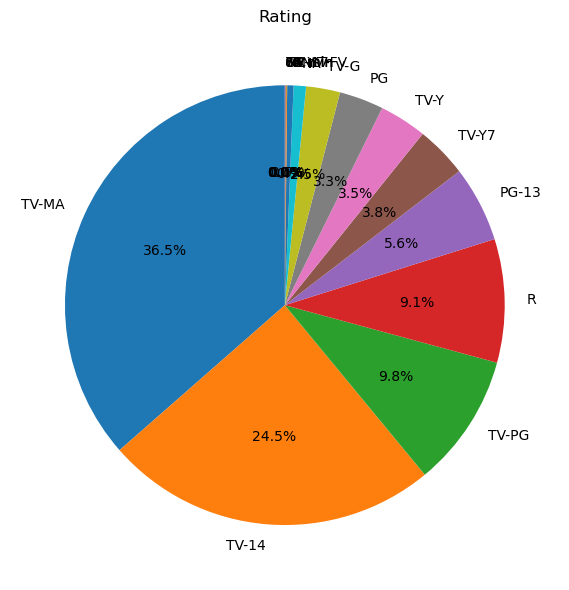

In [154]:
rating_count = df['rating'].value_counts()
plt.figure(figsize=(8,6))
plt.pie(rating_count, labels=rating_count.index , autopct='%1.1f%%' , startangle=90)
plt.title("Rating")
plt.tight_layout()
plt.savefig("Content_Rating.png")
plt.show()


* Movie duration distributed

In [155]:
df['duration'].head(10)

0       90 min
1    2 Seasons
2     1 Season
3     1 Season
4    2 Seasons
5     1 Season
6       91 min
7      125 min
8    9 Seasons
9      104 min
Name: duration, dtype: object

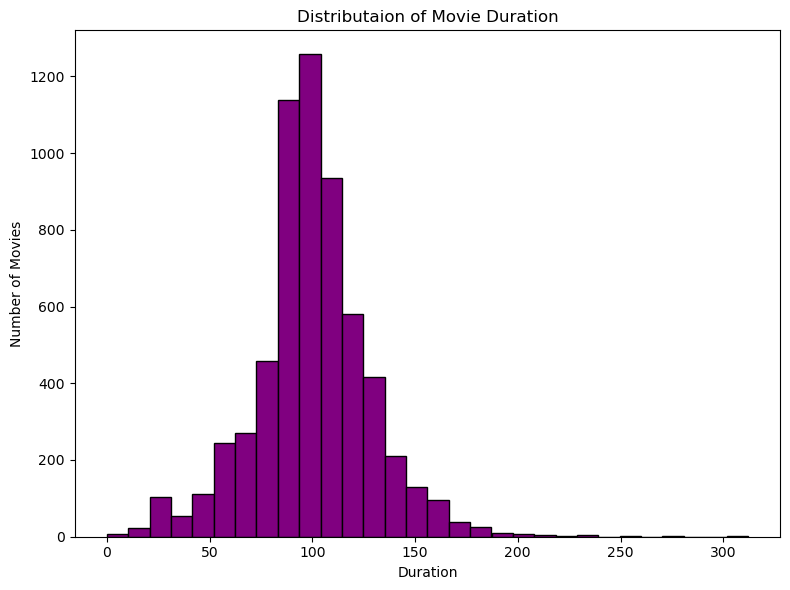

In [156]:
movie_df = df[df['type'] == 'Movie'].copy()

# 2. Strip the text and cast directly to int64
movie_df['duration_int'] = movie_df['duration'].str.replace(' min', '').fillna(0).astype('int64')

plt.figure(figsize = (8,6))
plt.hist(movie_df['duration_int'] , bins=30 , color='purple' , edgecolor = 'black')
plt.title("Distributaion of Movie Duration")
plt.xlabel("Duration")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.savefig("movie_duration.png")
plt.show()

* Release Year Vs No of Shows

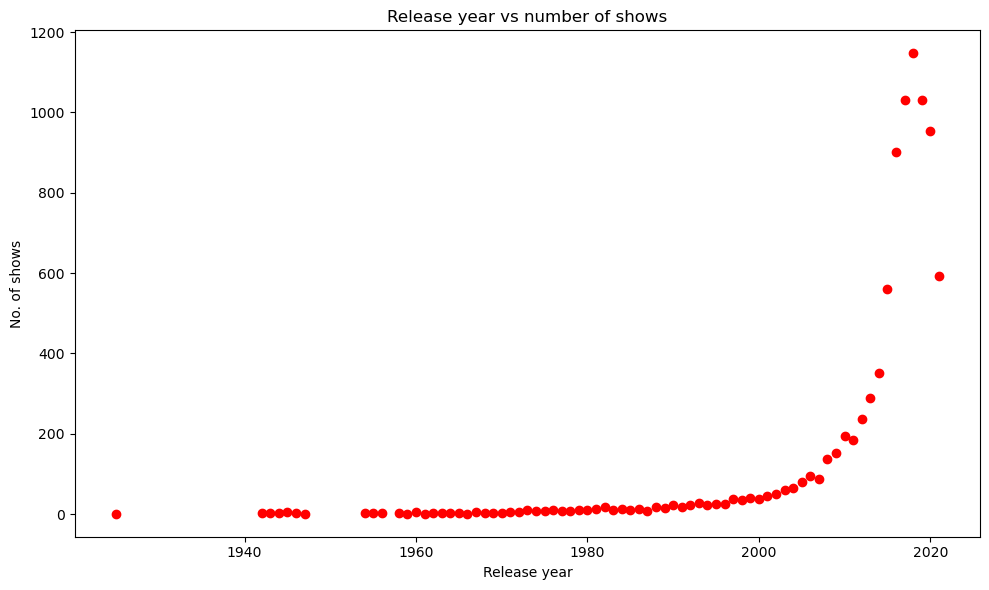

In [157]:
release_count = df['release_year'].value_counts().sort_index()

plt.figure(figsize = (10,6))
plt.scatter(release_count.index, release_count.values, color='red')
plt.title("Release year vs number of shows")
plt.xlabel("Release year")
plt.ylabel("No. of shows")
plt.tight_layout()
plt.savefig("release_year_shows.png")
plt.show()

* Top 10 Countries with higest shows

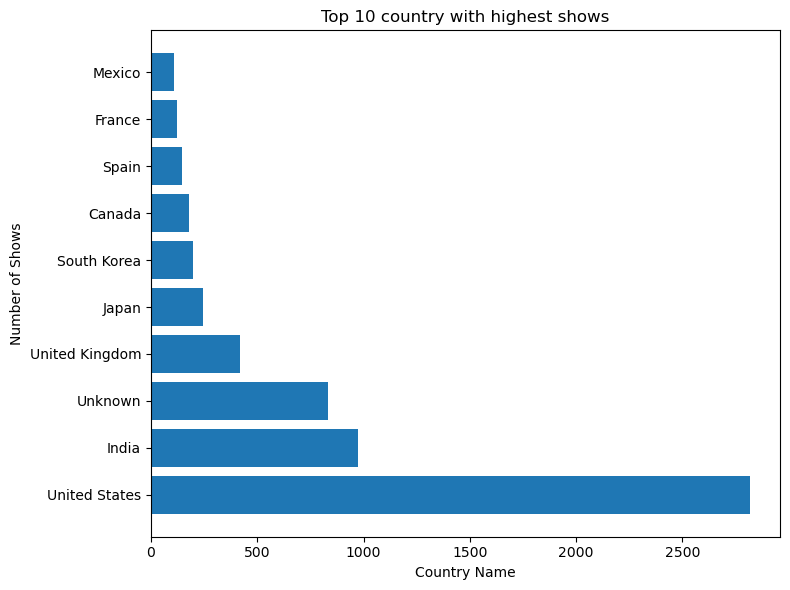

In [158]:
country_count = df['country'].value_counts().head(10)

plt.figure(figsize=(8,6))
plt.barh(country_count.index , country_count )
plt.title("Top 10 country with highest shows")
plt.xlabel("Country Name")
plt.ylabel("Number of Shows")
plt.tight_layout()
plt.savefig("top10_countries_scatter.png")
plt.show()

C:\Users\barea\AppData\Local\Temp\ipykernel_9332\1055618932.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


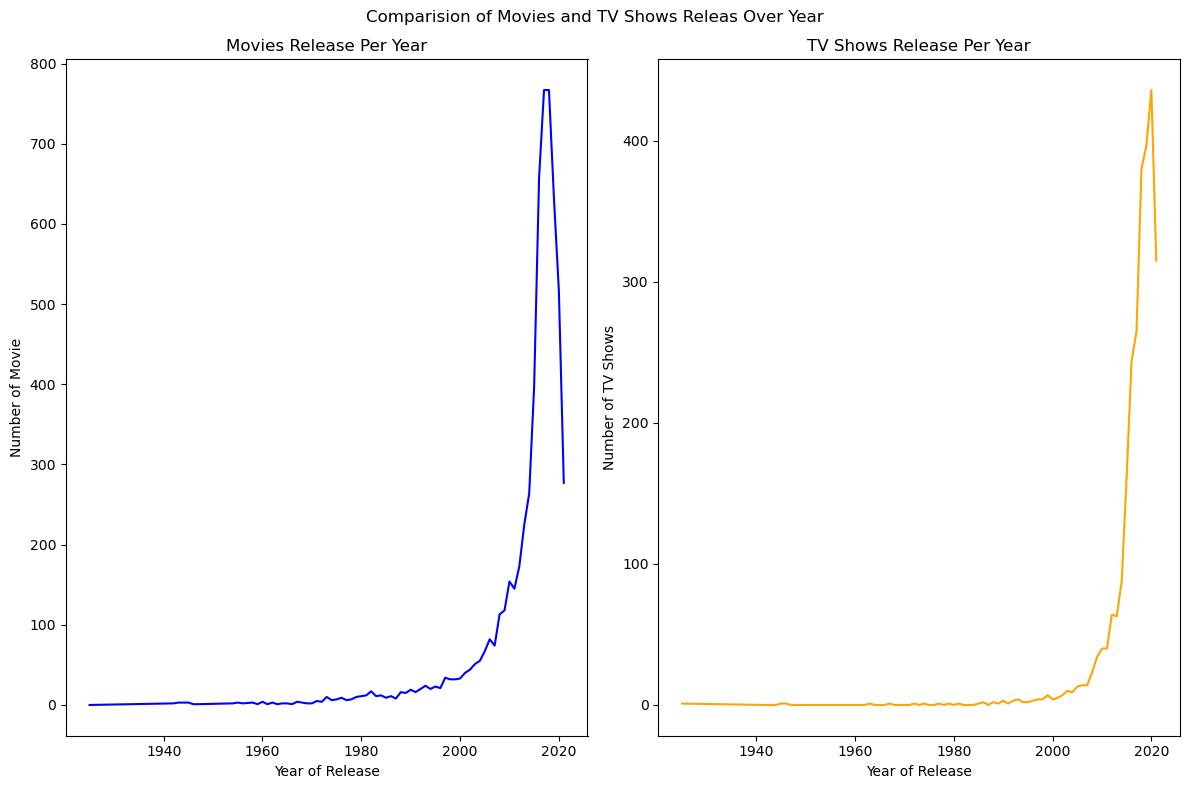

In [183]:
content_by_year = df.groupby(['release_year','type']).size().unstack().fillna(0)

fig,ax = plt.subplots(1,2, figsize =(12,8))


ax[0].plot(content_by_year.index , content_by_year['Movie'] , color='blue' , label='Movie')
ax[0].set_title("Movies Release Per Year")
ax[0].set_xlabel('Year of Release')
ax[0].set_ylabel("Number of Movie")

ax[1].plot(content_by_year.index , content_by_year['TV Show'], color='orange' ,label = 'Tv Show')
ax[1].set_title("TV Shows Release Per Year")
ax[1].set_xlabel('Year of Release')
ax[1].set_ylabel("Number of TV Shows")

fig.suptitle("Comparision of Movies and TV Shows Releas Over Year")
fig.tight_layout()
fig.savefig("movie_tv_shows_comparision.png")
fig.show()
